# Finding best fitting wavelet
Calculating complex amplitude by correlation match with the complex amplitude square of Gabor filter library decomposed visual stimulation, to similar to Skriabine S. et al 2026.

Results are saved to cell database pickel file.

In [21]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from tqdm import tqdm

from wavelet_utils import loadFilterParamDict
from analysis_utils import compute_respcorr_split_half, FeatureSearch_correlation_batched, dwt_amp_phase_torch_batched, sine1x, fit_sine1x

Expecting to have:
* Spikes of the neural data to analyze: npy file having array of (n_trials, n_timepoints, n_neurons)
* Filter library (and filter parameters file): see 2_gabor_library_test.ipynb
* Downsampled video: see 3_video_decomposition_test.ipynb
* Wavelet-decomposed data: see 3_video_decomposition_test.ipynb

* (optional) Cell database: cells_caiman.cellDB_pickle having records for each neuron - this will be extended with the calculated data

In [22]:
#jobFolder_str=r"GBM11\g11_0409_zebra"
jobFolder_str=r"GBM11\g11_0409_zebra5"
#jobFolder_str=r"GBM11\g11_0415_zebra5"
#jobFolder_str=r"GBM11\g11_0423_zebra6"
#jobFolder_str=r"GBM11\g11_0508_full"
#jobFolder_str=r"GBM15\g15_0408_zebra"
#jobFolder_str=r"GBM15\g15_0422_zebra3"

In [23]:
spks_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS\\resps_all.npy"

temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'



downsampled_video_path = Path(temppath) / r"zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled.npy"

# this analysis needs a library with last dimension being 2: phase of [0 90]
lib_dim="40_26_8_5_4_2" 
libpath= Path(temppath) / f'gaborLibrary_{lib_dim}.npy'
paramspath = libpath.with_suffix('.json')   
dwt_path = Path(temppath) / f"zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled_lib{lib_dim}_100_66dwt.npy"

print(libpath)
print(dwt_path)
print(spks_path)

D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_40_26_8_5_4_2.npy
D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled_lib40_26_8_5_4_2_100_66dwt.npy
D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\resps_all.npy


In [24]:
xs, ys, angles, sizes, freqs, phases, visual_coverage, full_screen_coverage, screen_x, screen_y = loadFilterParamDict(paramspath)

## Load data

In [25]:
spks=np.load(spks_path)
print(f"spks shape: {spks.shape} (n_trials, n_timepoints, n_neurons)")
working_dir = Path(spks_path).parent
print(f"Working directory: {working_dir}")

spks shape: (5, 12600, 2254) (n_trials, n_timepoints, n_neurons)
Working directory: D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS


In [26]:
# Repeatability
respcorr = compute_respcorr_split_half(spks)

# top 3 most repeatable neurons
top_neurons = np.argsort(respcorr)[-3:]
print(f"Top 3 most repeatable neurons: {top_neurons}")

Computing split-half correlation per neuron: 100%|██████████| 2254/2254 [00:06<00:00, 372.89it/s]

Top 3 most repeatable neurons: [1852 1820 2188]


## Correlate neural data with decomposed stimulus

In [27]:
#load inputs
dwt = np.load(dwt_path, mmap_mode='r' )
print(f"dwt shape: {dwt.shape}")

mean_spks = np.mean(spks[:, :, :], axis=0)
print(f"mean_spks shape: {mean_spks.shape}")
# do not restrict value dwt[dwt < 0] = 0
# do not take absolute value dwt=np.abs(dwt)

#Calculating squared amplitude and phase from the two phase DWT  
dwt_squared, dwt_phase=dwt_amp_phase_torch_batched(dwt)

dwt shape: (12600, 40, 26, 8, 5, 4, 2)
mean_spks shape: (12600, 2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Calculating DWT amplitude and phase: 100%|██████████| 50/50 [00:14<00:00,  3.48it/s]

| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| batch               :    71.09 MB  | shape=(56, 40, 26, 8, 5, 4, 2)  dtype=torch.float32
| real                :    35.55 MB  | shape=(56, 40, 26, 8, 5, 4)  dtype=torch.float32
| imag                :    35.55 MB  | shape=(56, 40, 26, 8, 5, 4)  dtype=torch.float32
| amp2                :    35.55 MB  | shape=(56, 40, 26, 8, 5, 4)  dtype=torch.float32
| phase               :    35.55 MB  | shape=(56, 40, 26, 8, 5, 4)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   213.28 MB (  1.7%) | RESERVED:  1580.00 MB ( 12.9%) | TOTAL GPU: 12281.50 MB  


In [28]:
## runs correlation calculation
rfs = FeatureSearch_correlation_batched( dwt_squared, mean_spks)

n_neurons = rfs.shape[0]

    stim_flat shape: (12600, 166400) (n_timepoints=12600, n_features=166400)
    resp shape: (12600, 2254) (n_timepoints=12600, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 17/17 [00:11<00:00,  1.43it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :   108.34 MB  | shape=(2254, 12600)  dtype=torch.float32
| S_chunk             :   307.62 MB  | shape=(6400, 12600)  dtype=torch.float32
| rfs_chunk           :    55.03 MB  | shape=(2254, 6400)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   470.99 MB (  3.8%) | RESERVED:  1778.00 MB ( 14.5%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 40, 26, 8, 5, 4) (neurons=2254, feature_dims=(40, 26, 8, 5, 4))


In [29]:
# fit angle tuning curve: sine
tuning_angles_fit=[]
for _idx in range(n_neurons):
    myrfs = rfs[_idx]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    tuning_curve_raw = myrfs[max_idx[0], max_idx[1], :, max_idx[3], max_idx[4]]
    
    params = fit_sine1x(angles, tuning_curve_raw)

    # interpolated fit
    angles_interp = np.linspace(0, 1*np.pi, 100)
    tuning_curve_fit_interp = sine1x(angles_interp, **params)
    
    tuning_angles_fit.append((params, angles_interp, tuning_curve_fit_interp))
    

In [30]:
# find maximum RF value for each neuron
max_values = []
for my_neuron in range(n_neurons):
    myrfs = rfs[my_neuron]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]
    max_values.append(max_value)
max_values = np.asarray(max_values)

In [31]:
#play: # save respcorr and max_values for each neuron to a csv file
df = pd.DataFrame({'respcorr': respcorr, 'max_values': max_values})
df.to_csv(working_dir / 'respcorr_max_values_5.csv', index=False)

In [32]:
#play: # find absolut maximum RF value across all neurons and features
max_idx = np.unravel_index(np.argmax(rfs), rfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = rfs[max_idx]
print(f"max RF value: {max_value} at index {max_idx}")

max RF value: 0.5814531445503235 at index (205, 7, 25, 5, 3, 3)


In [33]:
#play: #index of largest 20 respcorr values
largest_respcorr_indices = np.argsort(respcorr)[-20:]
print(f"Mean respcorr of largest 20 neurons: {np.mean(respcorr[largest_respcorr_indices])}")
print(f"Mean rfs_correlation of largest 20 neurons: {np.mean(max_values[largest_respcorr_indices])}")

Mean respcorr of largest 20 neurons: 0.734815765831713
Mean rfs_correlation of largest 20 neurons: 0.3376636505126953


In [34]:
#play: # find maximum RF value for a specific neuron
my_neuron = 456
# my_neuron = 1813 

myrfs = rfs[my_neuron]
max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = myrfs[max_idx]
print(f"Neuron {my_neuron} max RF value: {max_value:.3f} at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}")

Neuron 456 max RF value: 0.364 at index (17, 21, 0, 3, 2), respcorr: 0.743


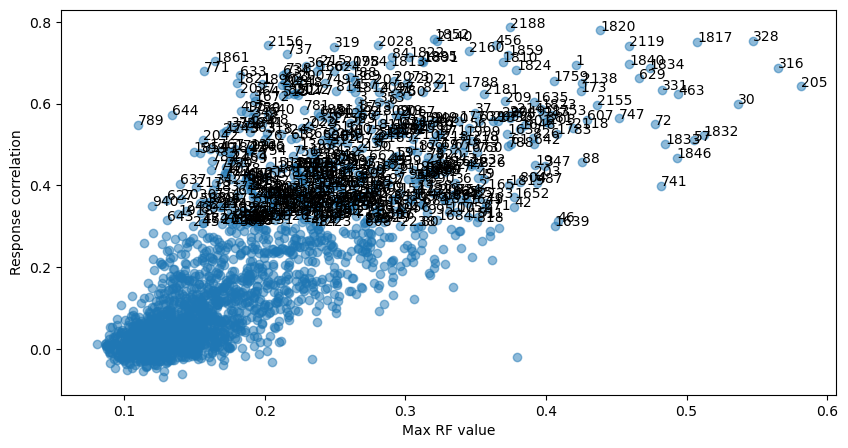

In [35]:
#play: # plot max_values vs respcorr with data labels
plt.figure(figsize=(10, 5))
plt.scatter(max_values, respcorr, alpha=0.5)

for i in range(n_neurons):
    if respcorr[i] > 0.3 and max_values[i] > 0.09: # only label neurons with high repeatability
        plt.annotate(f"{i}", (max_values[i], respcorr[i]))

plt.xlabel('Max RF value')
plt.ylabel('Response correlation')
plt.show()


In [36]:

library = np.load(libpath, mmap_mode='r')

downsampled_video=np.load(downsampled_video_path)
if downsampled_video.shape[0] != dwt.shape[0]:
    raise ValueError("downsampled_video and WT must have the same number of frames")

## Visualization

In [37]:
#plot interactive

#zoomwidth = 12 # 13hz resampling
zoomwidth = 28 # 30hz resampling

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

az_left, az_right, el_bottom, el_top = visual_coverage

param_names = ["x", "y", "angle", "size", "freq"]
param_values = [xs, ys, angles, sizes, freqs]

resp = mean_spks

n_frames = min(downsampled_video.shape[0], dwt.shape[0], resp.shape[0])
n_neurons = resp.shape[1]

slider_width = "300px"

sliders = [
    widgets.IntSlider(
        value=len(vals) // 2,
        min=0,
        max=len(vals) - 1,
        step=1,
        description=name,
        continuous_update=False,
        layout=widgets.Layout(width=slider_width)
    )
    for name, vals in zip(param_names, param_values)
]

neuron_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_neurons - 1,
    step=1,
    description="neuron",
    layout=widgets.Layout(width=slider_width)
)

time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    continuous_update=False,
    layout=widgets.Layout(width="100%")
)

time_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    layout=widgets.Layout(width=slider_width)
)

out_rfs = widgets.Output()
out_time = widgets.Output()
out_overlay = widgets.Output()

_updating_time = False
_updating_neuron = False


def set_sliders_to_neuron_max(my_neuron):
    myrfs = rfs[my_neuron]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]

    print(
        f"Neuron {my_neuron} max RF value: {max_value:.3f} "
        f"at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}"
    )

    for s, idx in zip(sliders, max_idx):
        s.value = idx
    time_slider.value = np.argmax(resp[:, my_neuron])

    return max_idx


def plot_view(*args):
    xi, yi, anglei, sizei, freqi = [s.value for s in sliders]
    ti = time_slider.value
    ni = neuron_box.value

    frame = downsampled_video[ti]
    filt = library[xi, yi, anglei, sizei, freqi, 0, :, :]

    #transient_p0 = dwt[:n_frames, xi, yi, anglei, sizei, freqi, 0]
    #transient_p1 = dwt[]:n_frames, xi, yi, anglei, sizei, freqi, 1]
    transient_p0 = dwt_squared[:n_frames, xi, yi, anglei, sizei, freqi]
    transient_p1 = dwt_phase[:n_frames, xi, yi, anglei, sizei, freqi] / (2 * np.pi) * np.max(transient_p0) 
    neuron_trace = resp[:n_frames, ni]

    current_rfs = rfs[ni, xi, yi, anglei, sizei, freqi]
    current_respcorr = respcorr[ni]

    title_params = (
        f"frame={ti}, neuron={ni}, respcorr={current_respcorr:.4f}, "
        f"rfs={current_rfs:.4f}\n"
        f"x={xs[xi]:.2f}, y={ys[yi]:.2f}, "
        f"angle={angles[anglei]:.2f}, "
        f"size={sizes[sizei]:.2f}, "
        f"freq={freqs[freqi]:.3f}, "
        f"phase=ampl**"
    )

    with out_rfs:
        out_rfs.clear_output(wait=True)

        fig, axes = plt.subplots(2, 3, figsize=(9, 5))
        axes = axes.flat

        cross_sections = [
            ("x", xs, rfs[ni, :, yi, anglei, sizei, freqi], xi),
            ("y", ys, rfs[ni, xi, :, anglei, sizei, freqi], yi),
            ("angle", angles, rfs[ni, xi, yi, :, sizei, freqi], anglei),
            ("size", sizes, rfs[ni, xi, yi, anglei, :, freqi], sizei),
            ("freq", freqs, rfs[ni, xi, yi, anglei, sizei, :], freqi),
        ]

        for ax, (name, vals, data, idx) in zip(axes, cross_sections):
            ax.plot(vals, data, marker="o")
            ax.axvline(vals[idx], color="red", linestyle="--", linewidth=1.5)
            ax.axhline(0, color="black", linewidth=0.5)
            ax.set_title(f"{name} | rfs={data[idx]:.4f}", fontsize=9)
            ax.set_xlabel(name)
            ax.set_ylabel("rfs")
            
        #angles plot different
        params, x_fit, y_fit = tuning_angles_fit[ni]
        axes[2].plot(x_fit, y_fit, marker="none", color="gray", linewidth=0.5)
        axes[2].axvline(params['orientation'], color="gray", linewidth=0.5)
        axes[2].axhline(params['constant'], linestyle="--", linewidth=0.5, color="gray")
        axes[2].set_title(f"angle | orientation={np.rad2deg(params['orientation']):.1f}", fontsize=9)
        


        fig.suptitle(f"RFS cross-sections — neuron {ni}", fontsize=11)
        plt.tight_layout()
        plt.show()

    with out_time:
        out_time.clear_output(wait=True)

        z0 = max(0, ti - zoomwidth)
        z1 = min(n_frames, ti + zoomwidth+1)
        t_zoom = np.arange(z0, z1)

        fig, (ax_zoom, ax_full) = plt.subplots(
            1, 2,
            figsize=(14, 3.5),
            gridspec_kw={"width_ratios": [1, 2]}
        )

        ax_full.plot(np.arange(n_frames), transient_p1, color="green", alpha=0.8)
        ax_full.plot(np.arange(n_frames), transient_p0, color="blue", alpha=0.8)
        ax_full.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_full.set_xlim(0, n_frames - 1)
        ax_full.set_xlabel("Frame")
        ax_full.set_title(
            f"WT + neuron transient — full | neuron={ni}, respcorr={current_respcorr:.4f}"
        )

        ax_full_r = ax_full.twinx()
        ax_full_r.plot(np.arange(n_frames), neuron_trace, color="orange", alpha=0.8)
        ax_full_r.set_ylabel("Neuron response")

        wt_ylim = ax_full.get_ylim()
        neuron_ylim = ax_full_r.get_ylim()

        ax_zoom.plot(t_zoom, transient_p1[z0:z1], marker="o", color="green")
        ax_zoom.plot(t_zoom, transient_p0[z0:z1], marker="o", color="blue")
        ax_zoom.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_zoom.set_xlim(z0, z1 - 1)
        ax_zoom.set_ylim(wt_ylim)
        ax_zoom.set_title(f"Zoom ±{zoomwidth} frames")
        ax_zoom.set_xlabel("Frame")
        ax_zoom.set_ylabel("DWT response (squared, phase)")

        ax_zoom_r = ax_zoom.twinx()
        ax_zoom_r.plot(t_zoom, neuron_trace[z0:z1], color="orange", marker=".")
        ax_zoom_r.set_ylim(neuron_ylim)

        ax_zoom_r.set_yticks([])
        ax_zoom_r.set_ylabel("")
        ax_zoom_r.spines["right"].set_visible(False)

        ax_full.set_yticks([])
        ax_full.set_ylabel("")
        ax_full.spines["left"].set_visible(False)

        plt.tight_layout()
        plt.show()

    with out_overlay:
        out_overlay.clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(7, 5))

        ax.imshow(
            frame.T,
            cmap="gray",
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",
        )

        filt_plot = filt.T
        v = np.max(np.abs(filt_plot))
        if v == 0:
            v = 1

        rgba = np.zeros((*filt_plot.shape, 4), dtype=float)
        pos = filt_plot > 0
        neg = filt_plot < 0

        rgba[pos, 0] = 1.0
        rgba[neg, 1] = 1.0
        rgba[..., 3] = np.abs(filt_plot) / v * 0.7

        ax.imshow(
            rgba,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",
        )

        ax.set_title("Video + selected Gabor overlay\n" + title_params)
        ax.set_xlabel("Azimuth (°)")
        ax.set_ylabel("Elevation (°)")

        plt.tight_layout()
        plt.show()


def sync_time_from_slider(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_box.value = change["new"]
    _updating_time = False
    plot_view()


def sync_time_from_box(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_slider.value = change["new"]
    _updating_time = False
    plot_view()


def update_neuron(change=None):
    global _updating_neuron
    if _updating_neuron:
        return

    _updating_neuron = True
    set_sliders_to_neuron_max(neuron_box.value)
    _updating_neuron = False

    plot_view()


for s in sliders:
    s.observe(plot_view, names="value")

time_slider.observe(sync_time_from_slider, names="value")
time_box.observe(sync_time_from_box, names="value")
neuron_box.observe(update_neuron, names="value")

slider_box = widgets.VBox([neuron_box] + sliders)
top_row = widgets.HBox([slider_box, out_rfs])
time_control = widgets.HBox([time_box, time_slider])

display(top_row, out_time, time_control, out_overlay)

update_neuron()

Output()

Output()

Neuron 0 max RF value: 0.300 at index (17, 20, 7, 3, 2), respcorr: 0.574


## Saving results

In [38]:
#save results into cell database
input_pickle_path= working_dir / "cells_caiman.cellDB_pickle"
if input_pickle_path.exists():
    df_cells=pd.read_pickle(open(input_pickle_path,"rb"))
else:
    df_cells = pd.DataFrame()
    for _idx in range(n_neurons): #handling only good components
            record={}
            record['cell_id'] = _idx
            record['SeriesID'] = 'unknown'
            df_cells = pd.concat([df_cells, pd.DataFrame([record])], ignore_index=True)

df_cells = df_cells.set_index("cell_id", drop=False)

df_cells["RF_indexes"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["WL_transient_squared"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["WL_transient_phase"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["Cell_activity"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_xs"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_ys"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_angles"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_sizes"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_freqs"] = pd.Series([None] * len(df_cells), dtype="object")


for _idx in tqdm(range(n_neurons)):
    df_cells.loc[_idx,'Repeatability'] = respcorr[_idx]
    
    myrfs = rfs[_idx]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]
    
    df_cells.at[_idx, 'RF_indexes'] = list(max_idx)
    df_cells.loc[_idx, 'RF_value'] = max_value
    
    df_cells.loc[_idx, 'Azimuth'] = xs[max_idx[0]]
    df_cells.loc[_idx, 'Elevation'] = ys[max_idx[1]]
    df_cells.loc[_idx, 'Angle'] = angles[max_idx[2]]
    df_cells.loc[_idx, 'Size'] = sizes[max_idx[3]]
    df_cells.loc[_idx, 'Frequency'] = freqs[max_idx[4]]


    transient_squared = dwt_squared[:, *max_idx]
    transient_phase = dwt_phase[:, *max_idx] 
    
    df_cells.at[_idx, 'WL_transient_squared'] = transient_squared
    df_cells.at[_idx, 'WL_transient_phase'] = transient_phase
    df_cells.at[_idx, 'Cell_activity'] = spks[:, :, _idx]
    
    #store tuning curves
    df_cells.at[_idx, 'tun_xs'] = rfs[:, max_idx[1], max_idx[2], max_idx[3], max_idx[4]]
    df_cells.at[_idx, 'tun_ys'] = rfs[max_idx[0], :, max_idx[2], max_idx[3], max_idx[4]]
    df_cells.at[_idx, 'tun_angles'] = rfs[max_idx[0], max_idx[1], :, max_idx[3], max_idx[4]]
    df_cells.at[_idx, 'tun_sizes'] = rfs[max_idx[0], max_idx[1], max_idx[2], :, max_idx[4]]
    df_cells.at[_idx, 'tun_freqs'] = rfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], :]
    
    #store angle fit
    params, x_fit, y_fit = tuning_angles_fit[_idx]
    df_cells.loc[_idx, 'Angle_fit_ori'] = params['orientation']
    df_cells.loc[_idx, 'Angle_fit_amplitude'] = params['amplitude']
    df_cells.loc[_idx, 'Angle_fit_constant'] = params['constant']
    df_cells.loc[_idx, 'Angle_fit_OSI'] = params['amplitude'] / (params['amplitude'] + params['constant'])

picles_path=working_dir / "cells_waven1.cellDB_pickle"
df_cells.to_pickle(picles_path)

# Saving cell database to xls file. Omitting complicated data
df_cells.drop(columns=['WL_transient_squared', 'WL_transient_phase', 'Cell_activity', 'contour', 'tun_xs', 'tun_ys', 'tun_angles', 'tun_sizes', 'tun_freqs'], inplace=True, errors='ignore')
df_cells.to_excel(working_dir / "cells_waven1.xlsx", index=False)

print(f"Saved cell database to {picles_path}")



100%|██████████| 2254/2254 [00:02<00:00, 1057.19it/s]


Saved cell database to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\cells_waven1.cellDB_pickle


In [39]:
print("Total number of cells:", n_neurons)
print("Accepted cells:", df_cells["Accepted"].sum())
print("Responsive cells:", (df_cells["Repeatability"] > 0.2).sum())
print(
    "Accepted responsive cells:",
    (df_cells["Accepted"] & (df_cells["Repeatability"] > 0.2)).sum()
)

Total number of cells: 2254
Accepted cells: 736
Responsive cells: 756
Accepted responsive cells: 472


In [40]:
print(jobFolder_str)

GBM11\g11_0409_zebra5
